# WaveSlide - Exploratory Data Analysis

# 1. Introduction

The EDA analyzes the image dataset used for WaveSlide. WaveSlide is a computer vision project focused on taking the need away of presentators to have a helper to control their presentation. For the data, the HaGRID dataset will be used, a dataset composed of variuos images of persons doing a certain gesture. This analysis will be focused on checking the quality of the data, class distribution, bounding boxes, intensity histograms, and possible preprocessing strategies.

WaveSlide will use 4 gestures for the action flow:
- two_up **->** siguiente diapositiva
- fist **->** diapositiva anterior
- like **->** pausar y reproducir video
- call **->** on and off

**The main objectives and sections of this EDA are the following:**
- Understand the dataset structure
- Check if image annotations are valid
- Analyze class balance
- Detect missing or corrupted images
- Analyze image sizes and aspect ratios
- Analyze pixel intensity histogram
- Analyze hand bounding boxes
- Identify possible transformations for preprocessing and augmentation
- Generate final insights before training the model.


## 2. Dataset Structure

### 2.1. Folder Structure

The raw dataset is located on data/raw/. And it is divided in the following structure:

```p
data/
    raw/
        images/
            gesture_class1/
                image1.jpg
                image2.jpg
                ...
            gesture_class2/
                image101.jpg
                iamge102.jpg
                ...
            ...
        annotations/
            gesture_class1.json
            gesture_class2.json
            ...
```

Each image is located on the images folder and inside its respective class folder. For example, the "thumbs_up" images are located in "data/raw/images/thumbs_up/" folder. And all the metadata of a certain image class is on "annotations/" folder, as a json for each class. 

### 2.2 Annotation files

Each annotation files contains metadata about the images such as:
- Image ID
- Bounding Boxes
- Labels
- Leading Confidence
- User ID

## 3. Data Loading

### 3.1. Import Libraries

In [30]:
import os
import json
from pathlib import Path
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import numpy as np

### 3.2. Define dataset paths

In [31]:
images_root = Path("../data/raw/images")
annotations_root = Path("../data/raw/annotations")

### 3.3. Build a annotation dataframe

In [32]:
df_rows = []

for annotation_file in annotations_root.glob("*.json"):
    # Extract class name
    class_name = annotation_file.stem
    # Corresponding image folder
    image_dir = images_root / class_name
    # Load JSON annotations
    with open(annotation_file, "r") as f:
        annotations = json.load(f)
    # iterate trhough the annotations
    for image_id, ann in annotations.items():
        # Build path based on the image_id on the annotation
        image_path = image_dir / f"{image_id}.jpg"

        # Iterate if there is multiple bounding boxes
        for bbox, label in zip(ann["bboxes"], ann["labels"]):
            df_rows.append({
                # Each column of the dataframe
                "image_id": image_id,
                "image_path": str(image_path),
                "image_exists": image_path.exists(),
                "label": label,
                "bbox_x": bbox[0],
                "bbox_y": bbox[1],
                "bbox_w": bbox[2],
                "bbox_h": bbox[3],
            })

df_annotations_raw = pd.DataFrame(df_rows)

## 4. Generic Dataset Overview

### 4.1. Number of images

In [33]:
hands_detected = df_annotations_raw.shape[0]
total_images_from_annotations = df_annotations_raw["image_path"].nunique()
total_images_from_files = df_annotations_raw[df_annotations_raw["image_exists"] == True]["image_path"].nunique()
images_with_only_one_hand = df_annotations_raw[~df_annotations_raw["image_id"].duplicated(keep=False)].shape[0]

In [34]:
print("Dataset shape")
print(f"Total amount of hands detected: {hands_detected}")
print(f"Total amount of images from annotations: {total_images_from_annotations}")
print(f"Total amount of images from files: {total_images_from_files}")
print(f"Total amount of missing images: {total_images_from_annotations-total_images_from_files}")
print(f"% of missing images in dataset: {round((total_images_from_annotations - total_images_from_files)/total_images_from_annotations*100, ndigits=3)} %")

Dataset shape
Total amount of hands detected: 137897
Total amount of images from annotations: 113357
Total amount of images from files: 28340
Total amount of missing images: 85017
% of missing images in dataset: 74.999 %


### 4.2. Dealing with missing images

For dealing with missing images its suggested to delete all the missing images paths from the dataframe, and also delete the "image_exists" columns that its whole purpose is checking if the image is missing or not.

In [35]:
# Implementing solution to continue EDA analysis. Creating a new df_testing to prevent modifying the original dataframe.
df_testing = df_annotations_raw[df_annotations_raw['image_exists'] == True].drop(columns=["image_exists"])
print(f"New account of images: {df_testing['image_id'].nunique()}")

New account of images: 28340


### 4.3. Dealing with images with 2 hands

To deal with images with 2 hands, its suggested to eliminate them for now, since they would cause much more preprocessing work and in WaveSlide the presentator has to show just one hand to change the slide.

In [36]:
df_testing = df_testing[~df_testing["image_id"].duplicated(keep=False)]
print(f"Final amount of images in the dataset: {df_testing.shape[0]}")

Final amount of images in the dataset: 22128


### 4.4. Class distribution

In [37]:
# Checking the value count of the labels
print(df_testing["label"].value_counts())

label
two_up        5875
call          5618
fist          5515
like          5119
no_gesture       1
Name: count, dtype: int64


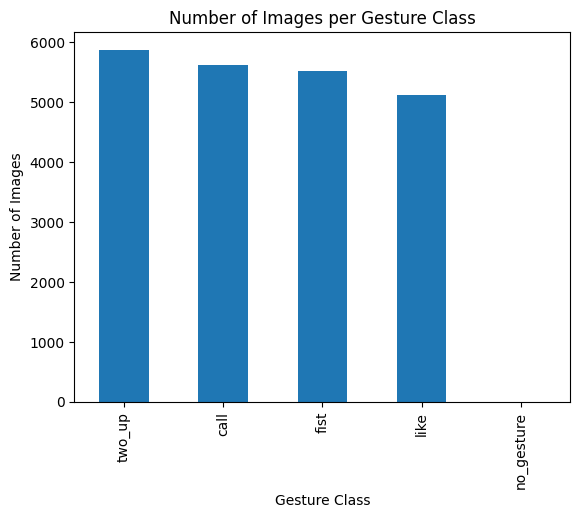

In [38]:
# Creating a plot for the class distribution
df_testing["label"].value_counts().plot(kind="bar")
plt.title("Number of Images per Gesture Class")
plt.xlabel("Gesture Class")
plt.ylabel("Number of Images")
plt.show()

### 4.5. Dealing with class imabalance
The plot and value_counts reveal that the class "no_gesture" has only 1 image assigned to it, making it meaningless to keep it as a training data. Its **suggested** to delete the image with this label.

In [39]:
df_testing = df_testing[~(df_testing["label"] == "no_gesture")]
print(df_testing["label"].value_counts())

label
two_up    5875
call      5618
fist      5515
like      5119
Name: count, dtype: int64


#### **Conclusions:**
**For Missing Images:**
The amount of images that are missing is a 75% of the whole dataset approximately. The amount of images after deleting the missing ones out of the dataframe would be 28340. The images that had 2 annotations (2 hands) when also removed leave the dataframe with 22128 available images. This amount is still pretty useful to train a gesture recognition model.

For the data preparation, the 2 actions done above are recommended.

**For Image Classes:**
The 4 gesture classes we are relatively balanced, only with the problem that there is a single row with a "no_gesture" class. In case for this EDA, the row was deleted for a better analysis.

For data preparation, the action above is recommended.

## 5. Image Resolution Analysis

### 5.1. Check for all resolutions of images

In [40]:
# Create a dataframe of resolutions and merge it with the original
df_resolution = []

for image_path in df_testing["image_path"]:
    img = cv2.imread(image_path)
    width, height = img.shape[:2]
    df_resolution.append({
        "image_path": image_path,
        "width": width,
        "height": height,
        "width_height": f"{width} {height}",
        "resolution_ratio": width/height
    })
df_resolution = pd.DataFrame(df_resolution)
df_testing = df_testing.merge(df_resolution, on="image_path", how="left")

In [41]:
# Check the new value counts for resolution ratio
print("Resolution ratio value counts: ")
print(df_testing["resolution_ratio"].value_counts())

Resolution ratio value counts: 
resolution_ratio
1.333333    12707
0.750000     2659
0.562225     1183
1.778646      841
1.335938      809
            ...  
1.674479        1
0.663212        1
1.393229        1
2.091146        1
0.771084        1
Name: count, Length: 234, dtype: int64


In [42]:
# Check the new value counts for width height pairs
print("Width-height pair value counts: ")
print(df_testing["width_height"].value_counts())

Width-height pair value counts: 
width_height
512 384    12707
384 512     2659
384 683     1183
683 384      841
513 384      809
           ...  
643 384        1
384 579        1
535 384        1
803 384        1
384 498        1
Name: count, Length: 234, dtype: int64


### 5.2. Dealing with the images resolutions

It can be seen that both resolution ratio and width_height pair share the amount of images on the different values. So we can confirm there is not a case of 2 images with different resolutions but the same ratio. For the analysis, we will remove the classes with different width_height pairs that aren't the same as the top one (512, 384).

In [43]:
df_testing = df_testing[df_testing["width_height"] == "512 384"]
print(f"New amount of images: {df_testing.shape[0]}")
print(f"New class distribution: {df_testing['label'].value_counts()}")

New amount of images: 12707
New class distribution: label
two_up    3433
call      3181
fist      3135
like      2958
Name: count, dtype: int64


#### **Conclusions**
The images come in different resolutions but the most frequent resolution is more than half of the total images. When taking away all the other images with different resolutions, we end up with 12707 images, that is still good amount of images to train our model.

It is recommended to do the action above.

## 6. Image colors

The images are in RGB format, but it is suggested to change the images to grayscale. The team decided this for the following reasons:
- The gesture recongition model needs to check for different patterns on the hand structure, not its color.
- The color of the hand could make the model search patterns on the coloring itself and downgrade the accuracy.
- Having colored images makes it more difficult to preprocess and check for intensity histograms.

In [44]:
# Creating the images grayscale and exporting it back to the dataset

# New path
path = "../data/eda_1_preprocessing/images"

Path(path).mkdir(parents=True, exist_ok=True)

for value in df_testing["label"].unique():
    Path(f"{path}/{value}").mkdir(parents=True, exist_ok=True)

for _, row in df_testing.iterrows():
    image_path = row["image_path"]
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    cv2.imwrite(f"{path}/{row['label']}/{row['image_id']}.jpg", img)

#### **Conclusions**
The images are turned to grayscale by the reasons explained above. In summary, this will help the model classify the images by the correct methods, and also help a lot in the preprocessing time.

It is recommended to do the action above.

## (6.5). Loading the new dataframe with the processed images

Loading the grayscale images to the new testing dataframe to do more analysis on it

In [45]:
# Path working
path = "../data/eda_1_preprocessing/images/"
df_testing["image_path"] = (
    path
    + df_testing["label"]
    + "/"
    + df_testing["image_id"]
    + ".jpg"
)

In [46]:
df_testing.head()

,image_id,image_path,label,bbox_x,bbox_y,bbox_w,bbox_h,width,height,width_height,resolution_ratio
1,0516ab39-9dd3-41bf-9707-ccea0dbf985f,../data/eda_1_preprocessing/images/call/0516ab...,call,0.400170,0.322325,0.130441,0.128704,512,384,512 384,1.333333
4,1eb5b012-ef66-48a3-81bc-f44a8e142f39,../data/eda_1_preprocessing/images/call/1eb5b0...,call,0.294010,0.316376,0.199615,0.104519,512,384,512 384,1.333333
6,23ceed35-7032-4eea-b27a-3868833418a0,../data/eda_1_preprocessing/images/call/23ceed...,call,0.499256,0.475753,0.184818,0.129802,512,384,512 384,1.333333
8,31121d1c-d696-4886-98cd-218594b4a953,../data/eda_1_preprocessing/images/call/31121d...,call,0.274070,0.301205,0.194231,0.132940,512,384,512 384,1.333333
9,35bbb06f-cf51-45dd-aef1-224d09686760,../data/eda_1_preprocessing/images/call/35bbb0...,call,0.370299,0.320113,0.299563,0.190778,512,384,512 384,1.333333


*Visualizamos las iamgenes*

Proyectando bboxes normalizados sobre las imágenes filtradas...


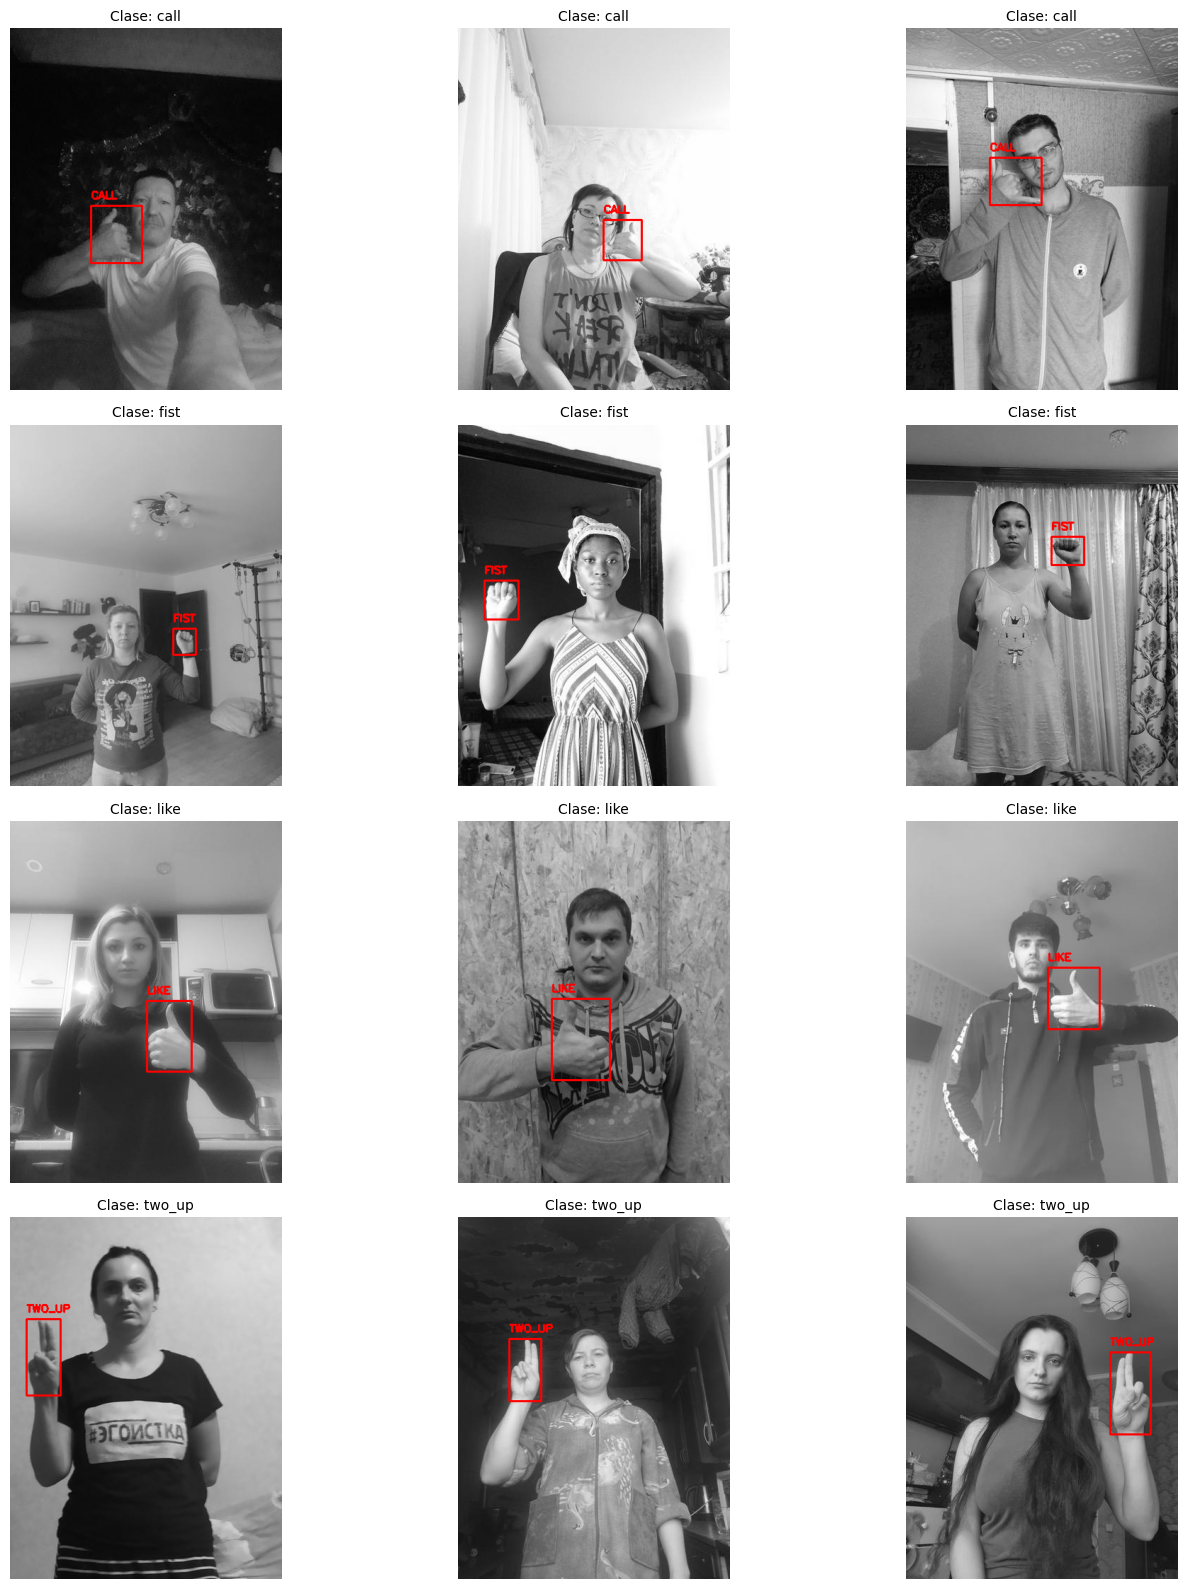

In [47]:
# Obtener las clases únicas (call, fist, like, two_up)
clases = df_testing['label'].unique()
imagenes_por_clase = 3

# Configurar la cuadrícula (Filas = Clases, Columnas = 3 muestras)
fig, axes = plt.subplots(len(clases), imagenes_por_clase, figsize=(15, 4 * len(clases)))

print("Proyectando bboxes normalizados sobre las imágenes filtradas...")

for i, clase in enumerate(clases):
    # Filtrar por clase actual
    df_clase = df_testing[df_testing['label'] == clase]
    
    # Seleccionar 3 muestras aleatorias
    muestras = df_clase.sample(n=min(imagenes_por_clase, len(df_clase)), random_state=42)
    
    for j, (_, row) in enumerate(muestras.iterrows()):
        img_path = row['image_path']
        
        # Leer la imagen en escala de grises procesada (Mediana + CLAHE)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        ax = axes[i, j] if len(clases) > 1 else axes[j]
        
        if img is not None:
            # Capturar el tamaño real de la imagen leída (Alto, Ancho)
            alto_efectivo, ancho_efectivo = img.shape[:2]
            
            # Pasar a RGB para pintar la caja en color contrastante
            img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            
            # Desnormalizar temporalmente SOLO para la pantalla usando las dimensiones reales
            x = int(row['bbox_x'] * ancho_efectivo)
            y = int(row['bbox_y'] * alto_efectivo)
            w = int(row['bbox_w'] * ancho_efectivo)
            h = int(row['bbox_h'] * alto_efectivo)
            
            # Dibujar el rectángulo rojo sobre la mano
            cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (255, 0, 0), 2)
            
            # Agregar la etiqueta del gesto arriba del recuadro
            cv2.putText(img_rgb, row['label'].upper(), (x, max(y - 10, 15)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
            
            # Mostrar en la cuadrícula
            ax.imshow(img_rgb)
            ax.set_title(f"Clase: {clase}", fontsize=10)
            ax.axis('off')
        else:
            ax.text(0.5, 0.5, "Error al cargar\nla imagen", ha='center', va='center', color='red')
            ax.axis('off')

plt.tight_layout()
plt.show()

## 7. Normalizar los bbox

In [48]:
df_testing.head()

,image_id,image_path,label,bbox_x,bbox_y,bbox_w,bbox_h,width,height,width_height,resolution_ratio
1,0516ab39-9dd3-41bf-9707-ccea0dbf985f,../data/eda_1_preprocessing/images/call/0516ab...,call,0.400170,0.322325,0.130441,0.128704,512,384,512 384,1.333333
4,1eb5b012-ef66-48a3-81bc-f44a8e142f39,../data/eda_1_preprocessing/images/call/1eb5b0...,call,0.294010,0.316376,0.199615,0.104519,512,384,512 384,1.333333
6,23ceed35-7032-4eea-b27a-3868833418a0,../data/eda_1_preprocessing/images/call/23ceed...,call,0.499256,0.475753,0.184818,0.129802,512,384,512 384,1.333333
8,31121d1c-d696-4886-98cd-218594b4a953,../data/eda_1_preprocessing/images/call/31121d...,call,0.274070,0.301205,0.194231,0.132940,512,384,512 384,1.333333
9,35bbb06f-cf51-45dd-aef1-224d09686760,../data/eda_1_preprocessing/images/call/35bbb0...,call,0.370299,0.320113,0.299563,0.190778,512,384,512 384,1.333333


## 8. Intensity Histograms

Calculando histogramas individuales...


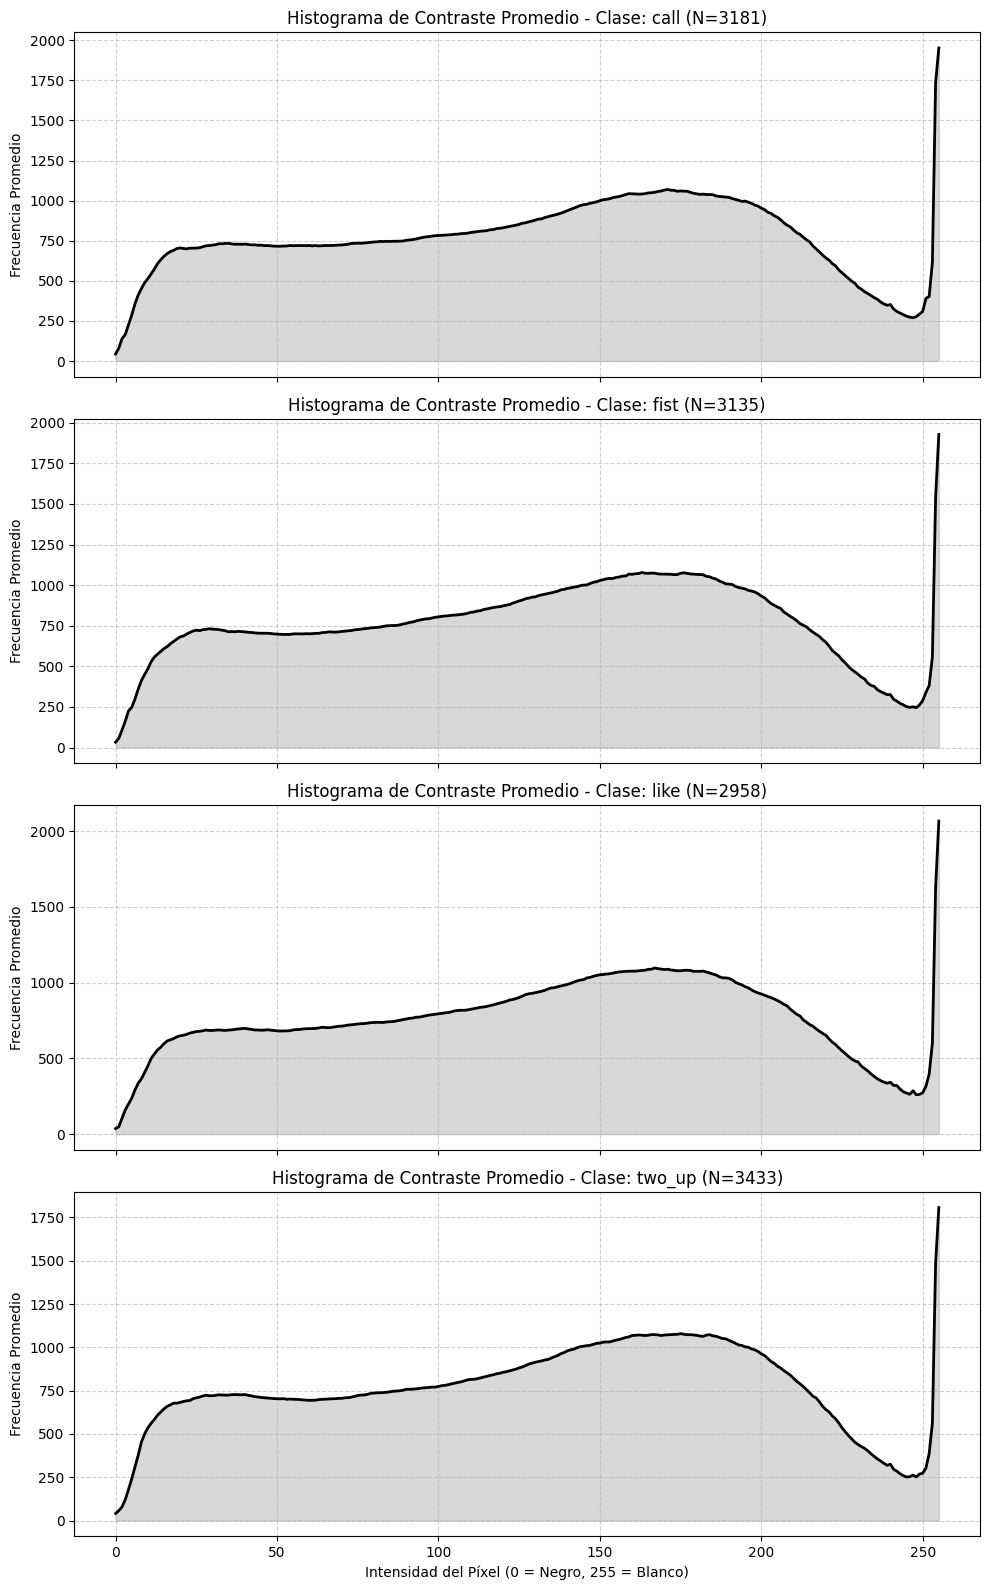

In [49]:

# Diccionario para acumular los histogramas de cada clase
clases = df_testing['label'].unique()
histogramas_por_clase = {clase: np.zeros(256) for clase in clases}
conteo_por_clase = {clase: 0 for clase in clases}

print("Calculando histogramas individuales...")

# Recorrer el dataframe para calcular el histograma de cada imagen
for _, row in df_testing.iterrows():
    img_path = row['image_path']
    clase = row['label']
    
    # Leer en escala de grises (por seguridad forzamos el flag IMREAD_GRAYSCALE)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    if img is not None:
        # Calcular histograma: [img], canal 0, sin máscara, 256 bins, rango [0, 256]
        hist = cv2.calcHist([img], [0], None, [256], [0, 256])
        
        # Acumular el histograma en su respectiva clase
        histogramas_por_clase[clase] += hist.flatten()
        conteo_por_clase[clase] += 1

# Graficar un histograma por cada clase
fig, axes = plt.subplots(len(clases), 1, figsize=(10, 4 * len(clases)), sharex=True)

for i, clase in enumerate(clases):
    # Promediar el histograma para que la escala sea independiente de la cantidad de fotos
    if conteo_por_clase[clase] > 0:
        hist_promedio = histogramas_por_clase[clase] / conteo_por_clase[clase]
    else:
        hist_promedio = histogramas_por_clase[clase]
        
    ax = axes[i] if len(clases) > 1 else axes
    ax.plot(hist_promedio, color='black', lw=2)
    ax.fill_between(range(256), hist_promedio, color='gray', alpha=0.3)
    ax.set_title(f"Histograma de Contraste Promedio - Clase: {clase} (N={conteo_por_clase[clase]})")
    ax.set_ylabel("Frecuencia Promedio")
    ax.grid(True, linestyle='--', alpha=0.6)

plt.xlabel("Intensidad del Píxel (0 = Negro, 255 = Blanco)")
plt.tight_layout()
plt.show()

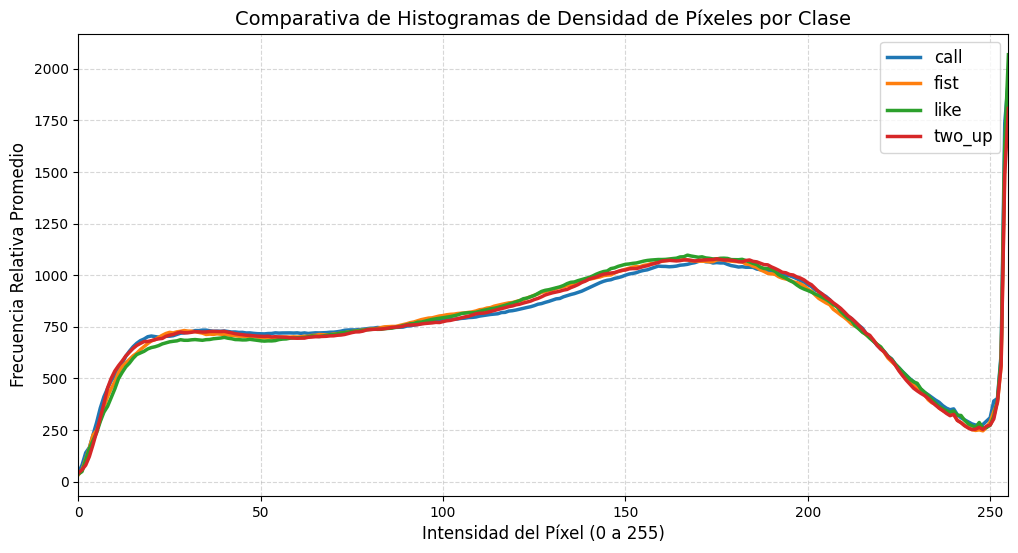

In [50]:
plt.figure(figsize=(12, 6))

# Usaremos una paleta de colores fija para identificar cada clase claramente
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, clase in enumerate(clases):
    if conteo_por_clase[clase] > 0:
        # Normalizamos dividiendo entre el total de píxeles promedio para poder comparar curvas limpiamente
        hist_normalizado = histogramas_por_clase[clase] / conteo_por_clase[clase]
        
        # Graficar la línea de la clase actual
        plt.plot(hist_normalizado, label=f"{clase}", color=colores[i % len(colores)], lw=2.5)

plt.title("Comparativa de Histogramas de Densidad de Píxeles por Clase", fontsize=14)
plt.xlabel("Intensidad del Píxel (0 a 255)", fontsize=12)
plt.ylabel("Frecuencia Relativa Promedio", fontsize=12)
plt.xlim([0, 255])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12, loc='upper right')
plt.show()

## 9. Filtros

In [51]:

# La ruta donde están tus imágenes en gris actualmente
path_grises = Path("../data/eda_1_preprocessing/images")

print("Aplicando filtro Gaussiano sutil para restaurar la nitidez de las manos...")

# Recorremos tu df_testing actual, que ya apunta a eda_1_preprocessing
for idx, row in df_testing.iterrows():
    image_path = row["image_path"]
    
    # Leer la imagen en escala de grises
    img_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    if img_gray is not None:
        # Filtro Gaussiano ultra ligero (kernel de 3x3)
        # Elimina ruido digital de fondo pero no deforma las manos pequeñas
        img_smooth = cv2.GaussianBlur(img_gray, (3, 3), 0)
        
        # Sobreescribimos la imagen en la misma ruta con el filtro correcto
        cv2.imwrite(image_path, img_smooth)

print("¡Procesamiento completado! Tus imágenes en gris ahora están limpias y nítidas.")

Aplicando filtro Gaussiano sutil para restaurar la nitidez de las manos...
¡Procesamiento completado! Tus imágenes en gris ahora están limpias y nítidas.


Renderizando muestras con siluetas mejoradas y bboxes originales...


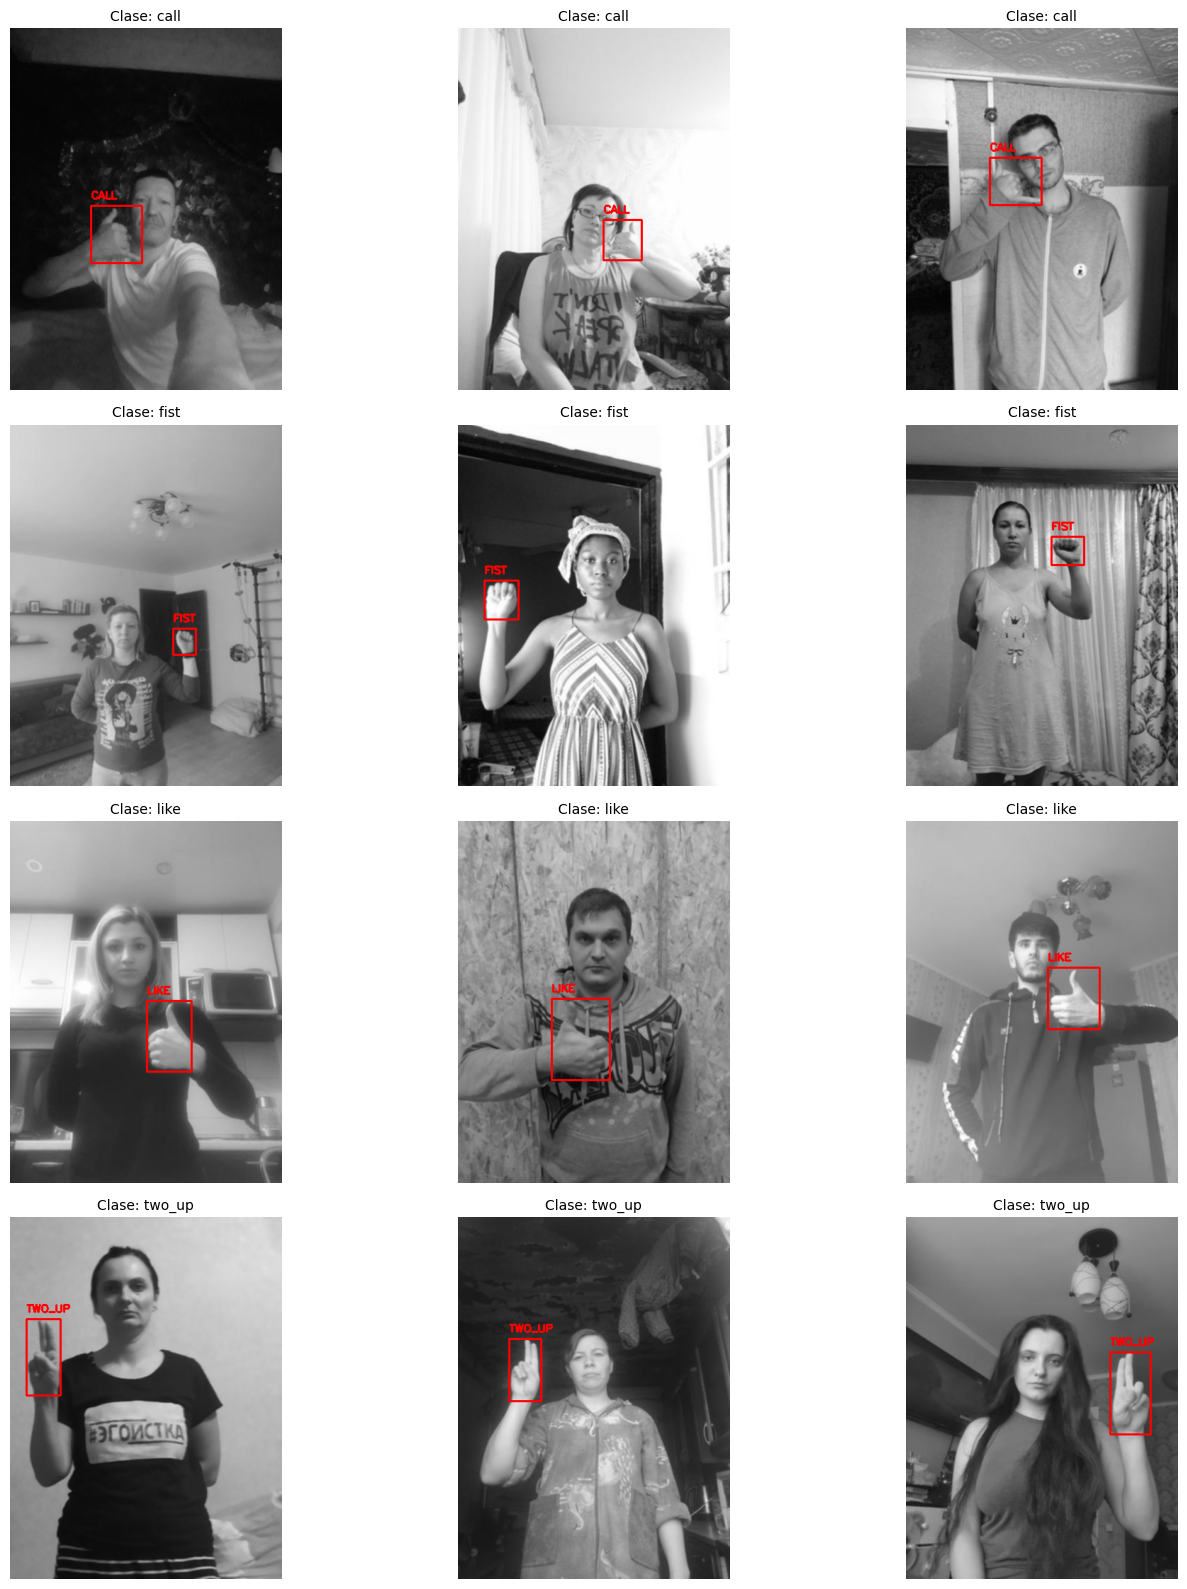

In [52]:

clases = df_testing['label'].unique()
imagenes_por_clase = 3

fig, axes = plt.subplots(len(clases), imagenes_por_clase, figsize=(15, 4 * len(clases)))

print("Renderizando muestras con siluetas mejoradas y bboxes originales...")

for i, clase in enumerate(clases):
    df_clase = df_testing[df_testing['label'] == clase]
    muestras = df_clase.sample(n=min(imagenes_por_clase, len(df_clase)), random_state=42)
    
    for j, (_, row) in enumerate(muestras.iterrows()):
        img_path = row['image_path']
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        ax = axes[i, j] if len(clases) > 1 else axes[j]
        
        if img is not None:
            # Obtener el tamaño de la imagen procesada (Alto, Ancho)
            alto_efectivo, ancho_efectivo = img.shape[:2]
            
            img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            
            # Desnormalizar en la pantalla usando el tamaño real detectado
            x = int(row['bbox_x'] * ancho_efectivo)
            y = int(row['bbox_y'] * alto_efectivo)
            w = int(row['bbox_w'] * ancho_efectivo)
            h = int(row['bbox_h'] * alto_efectivo)
            
            # Dibujar la caja delimitadora y la etiqueta
            cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (255, 0, 0), 2)
            cv2.putText(img_rgb, row['label'].upper(), (x, max(y - 10, 15)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
            
            ax.imshow(img_rgb)
            ax.set_title(f"Clase: {clase}", fontsize=10)
            ax.axis('off')
        else:
            ax.text(0.5, 0.5, "Error al cargar", ha='center', va='center', color='red')
            ax.axis('off')

plt.tight_layout()
plt.show()

Calculando los nuevos histogramas tras el filtro Gaussiano sutil...


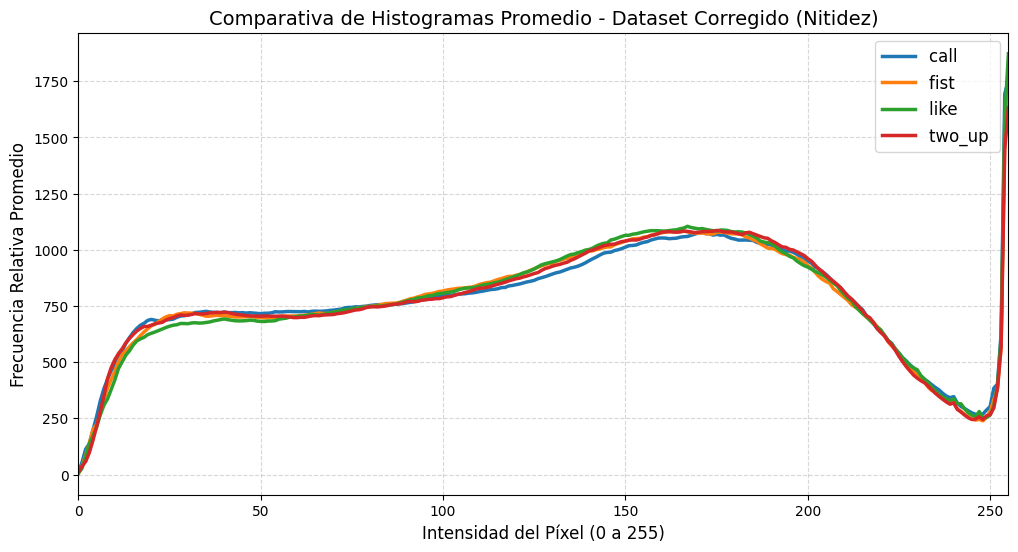

In [53]:
# Diccionario para acumular los nuevos histogramas de cada clase
clases = df_testing['label'].unique()
histogramas_por_clase = {clase: np.zeros(256) for clase in clases}
conteo_por_clase = {clase: 0 for clase in clases}

print("Calculando los nuevos histogramas tras el filtro Gaussiano sutil...")

# Recorrer tu df_testing para procesar colectivamente tus miles de imágenes
for _, row in df_testing.iterrows():
    img_path = row['image_path']
    clase = row['label']
    
    # Leer la imagen corregida en escala de grises
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    if img is not None:
        # Calcular histograma individual
        hist = cv2.calcHist([img], [0], None, [256], [0, 256])
        
        # Acumular frecuencias
        histogramas_por_clase[clase] += hist.flatten()
        conteo_por_clase[clase] += 1

# GRAFICAR TODAS LAS CLASES JUNTAS (SUPERPUESTOS)
plt.figure(figsize=(12, 6))
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, clase in enumerate(clases):
    if conteo_por_clase[clase] > 0:
        # Promediar el histograma para que las curvas sean comparables
        hist_normalizado = histogramas_por_clase[clase] / conteo_por_clase[clase]
        
        # Graficar línea de la clase actual
        plt.plot(hist_normalizado, label=f"{clase} ", color=colores[i % len(colores)], lw=2.5)

plt.title("Comparativa de Histogramas Promedio - Dataset Corregido (Nitidez)", fontsize=14)
plt.xlabel("Intensidad del Píxel (0 a 255)", fontsize=12)
plt.ylabel("Frecuencia Relativa Promedio", fontsize=12)
plt.xlim([0, 255])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12, loc='upper right')
plt.show()

Viendo el grafico, vemos que no ha cambiado, pues de por si las imagenes de las manos son muy pequeños comparado con la proporción de toda la imagen, por lo que, al aplicar filtros muy fuertes solo generamos perdida de información. Las imagenes estan bien tal y como está para su procesamiento a un modelo de entrenamiento.

In [54]:
print(df_testing.shape[0])

12707


In [55]:
# 1. Al estar normalizados (0 a 1), la multiplicación directa ya te da el ratio de la pantalla
df_testing['hand_ratio'] = df_testing['bbox_w'] * df_testing['bbox_h']

# 2. Ver el resumen estadístico real de los tamaños
print("Resumen estadístico del tamaño de las manos:")
print(df_testing['hand_ratio'].describe())

Resumen estadístico del tamaño de las manos:
count    12707.000000
mean         0.026124
std          0.021637
min          0.000782
25%          0.012018
50%          0.020813
75%          0.033530
max          0.387166
Name: hand_ratio, dtype: float64


La mano más grande ocupa el 39% del tamanño de la pantalla, y que en promedio las imagenes ocupan solo el 3% aproximadamente de la pantalla. 